# day 19 | 251010 F

```python
def bisection(function, lower_guess, upper_guess, tolerance=2**-32):
    midpoint = (lower_guess + upper_guess)/2
    while upper_guess - lower_guess > tolerance:
        if function(lower_guess)*function(midpoint)<0:
            upper_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(midpoint)*function(upper_guess)<0:
            lower_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(lower_guess)*function(midpoint)>0 and function(midpoint)*function(upper_guess)>0:
            print('no unique root in that bracket')
            break
    return(midpoint)

def newton(f, df, guess, tolerance = 2**-32):
    x = guess
    n = 0
    while abs(f(x)) > tolerance:
        x = x - f(x)/df(x)
        n += 1
    return(x, n)

def secant(f, guess, delta, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x1 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        n += 1
    return(x1, n)
```



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def bisection(function, lower_guess, upper_guess, tolerance=2**-32):
    midpoint = (lower_guess + upper_guess)/2
    n = 0
    while upper_guess - lower_guess > tolerance:
        if function(lower_guess)*function(midpoint)<0:
            upper_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(midpoint)*function(upper_guess)<0:
            lower_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(lower_guess)*function(midpoint)>0 and function(midpoint)*function(upper_guess)>0:
            print('no unique root in that bracket')
            break
        n = n+1
    return(midpoint, n)

def newton(f, df, guess, tolerance = 2**-32):
    x = guess
    n = 0
    while abs(f(x)) > tolerance:
        x = x - f(x)/df(x)
        n += 1
    return(x, n)

def secant(f, guess, delta, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x1 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        n += 1
    return(x1, n)


In [11]:
def f(x):
    return(5*np.exp(-x)+x-5)

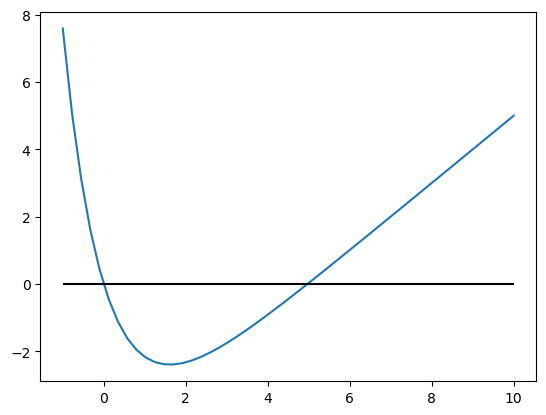

In [20]:
fig, ax = plt.subplots()

x = np.linspace(-1,10)
y = f(x)

ax.plot(x,y)
ax.hlines(0, x[0], x[-1],'k')

In [13]:
bisection(f, 4, 6)

(4.9651142318034545, 33)

In [14]:
def df(x):
    return(-5*np.exp(-x)+1)

In [18]:
newton(f, df, 0)

(0, 0)

In [21]:
secant(f, 10, 1)

(4.965114231761079, 7)